# Классификация сообщений мессенджера Авито
## Этап 1 — разведочный анализ и подготовка датасета

**Цель проекта**: автоматически определять, является ли сообщение нормальным, спамом, харассментом или угрозой, и ограничивать отправку нежелательного контента.

**Исходные данные**:
- `messages_project_aaa.csv` — 492 800 сырых сообщений с `message_id`, `text`, `item_title`
- `final_labeled_data_v1.csv` — 367 744 размеченных строк (включая синтетику)

**Структура ноутбука**:
1. Загрузка и первичный осмотр
2. Диагностика качества датасета
3. EDA: распределения, длины, примеры
4. Подготовка тренировочного датасета
5. Train / Val / Test разбивка
6. Итоги и выводы


## 0. Импорты и настройки

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # ноутбук запускается из папки notebooks/
                                             # или из корня проекта

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# Локальные модули
from src.data_prep import (
    load_raw, load_labeled, merge_with_labels,
    clean, add_text_features, make_train_ready,
    split, save_splits, split_stats, quality_report,
    NORMAL_CAP,
)
from src.eda_plots import (
    full_eda_grid, plot_quality_issues,
    plot_train_val_test_split, CLASS_RU, CLASS_ORDER,
)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.1f}".format)
print("✓ Импорты успешны")


✓ Импорты успешны


## 1. Загрузка данных

In [2]:
RAW_PATH     = "messages_project_aaa.csv"
LABELED_PATH = "final_labeled_data_v1.csv"

raw     = load_raw(RAW_PATH)
labeled = load_labeled(LABELED_PATH)

print("=== Сырые данные (messages_project_aaa) ===")
display(raw.head(3))
print(f"\nРазмер: {raw.shape[0]:,} строк × {raw.shape[1]} колонки")
print(f"Уникальных текстов: {raw['text'].nunique():,}")
print(f"Дублей по тексту: {raw.duplicated(subset=['text']).sum():,}")


=== Сырые данные (messages_project_aaa) ===


,message_id,text,item_title
0,73e26077-c009-43f5-9280-72d9da5940de,"Здравствуйте, когда можно забрать?",Глиняный сервиз
1,543764ff-e104-4989-9ca8-ae281c623092,"Доброе утро, все хорошо, Яна Кристина связалась со мной, вопрос решён! Извин...","1-к. квартира, 30 м², 1/5 эт."
2,b02531aa-a792-409b-a8c5-a6bff18646e7,Мотоцикл продали!,Продам мотоцикл



Размер: 492,800 строк × 3 колонки
Уникальных текстов: 361,600
Дублей по тексту: 131,200


In [3]:
print("=== Размеченные данные (final_labeled_data_v1) ===")
display(labeled.head(3))
print(f"\nРазмер: {labeled.shape[0]:,} строк × {labeled.shape[1]} колонки")
print(f"\nРаспределение классов:")
display(labeled["label"].value_counts().rename("count").to_frame())


=== Размеченные данные (final_labeled_data_v1) ===


,text,item_title,label,synthetic,source
0,"Здравствуйте, когда можно забрать?",Глиняный сервиз,normal,0,real
1,"Доброе утро, все хорошо, Яна Кристина связалась со мной, вопрос решён! Извин...","1-к. квартира, 30 м², 1/5 эт.",normal,0,real
2,Мотоцикл продали!,Продам мотоцикл,normal,0,real



Размер: 367,744 строк × 5 колонки

Распределение классов:


,count
label,
normal,356954
external,8190
spam,2220
harassment,291
threat,81


## 2. Диагностика качества датасета

### Ключевые проблемы:

| Проблема | Описание |
|---|---|
| **Критический дисбаланс** | 97% сообщений — класс «normal» |
| **Мало реальных примеров** | Угрозы: 4 реальных (95% синтетика!), Харассмент: 87 реальных |
| **Пропуски** | 122 пустых текста, 8 без метки |
| **Дубликаты** | 131 200 дублей в raw-файле |
| **Синтетика** | 70–95% миноритарных классов — сгенерированные данные |


In [4]:
print("=== Пропущенные значения в labeled ===")
print(labeled[["text", "label"]].isnull().sum())

print("\n=== Дубликаты ===")
print(f"Дублей по тексту: {labeled.duplicated(subset=['text']).sum():,}")
print(f"Дублей по (текст+метка): {labeled.duplicated(subset=['text','label']).sum():,}")

print("\n=== Реальные vs Синтетические по классу ===")
cross = labeled.groupby(["label", "source"]).size().unstack(fill_value=0)
cross.columns = ["Реальные", "Синтетические"]
cross["% синтетики"] = (
    cross["Синтетические"] / (cross["Реальные"] + cross["Синтетические"]) * 100
).round(1)
display(cross.reindex(CLASS_ORDER).fillna(0))


=== Пропущенные значения в labeled ===
text     122
label      8
dtype: int64

=== Дубликаты ===
Дублей по тексту: 309


Дублей по (текст+метка): 302

=== Реальные vs Синтетические по классу ===


,Реальные,Синтетические,% синтетики
label,,,
normal,356954,0,0.0
external,4327,3863,47.2
spam,220,2000,90.1
harassment,87,204,70.1
threat,4,77,95.1


## 3. EDA: исходный датасет

In [5]:
# Подготовим датасет с признаками для EDA
df_eda = add_text_features(labeled.dropna(subset=["text", "label"]))

# Сводная таблица по классам
print("=== Описательная статистика длины текста по классам ===")
display(df_eda.groupby("label")[["text_len", "word_count"]].describe().round(1))


=== Описательная статистика длины текста по классам ===


text_len                                         word_count       \
              count  mean   std  min  25%  50%   75%    max      count mean   
label                                                                         
external     8183.0 149.4 186.2  1.0 31.0 76.0 211.0 2328.0     8183.0 21.5   
harassment    291.0  65.5  71.0  3.0 22.0 45.0  78.0  546.0      291.0 11.0   
normal     356954.0  55.0  80.2  1.0 21.0 35.0  59.0 1460.0   356954.0  8.6   
spam         2105.0 142.7 140.6  8.0 66.0 97.0 150.0 1050.0     2105.0 24.5   
threat         81.0  59.7  47.9 11.0 29.0 47.0  63.0  260.0       81.0  9.8   

                                          
            std min  25%  50%  75%   max  
label                                     
external   26.2 0.0  5.0 12.0 30.0 332.0  
harassment 11.5 1.0  4.0  7.0 13.5  81.0  
normal     12.4 1.0  3.0  5.0  9.0 217.0  
spam       24.2 2.0 12.0 17.0 26.0 194.0  
threat      8.0 2.0  5.0  8.0 10.0  37.0

Сохранено: eda_report_initial.png


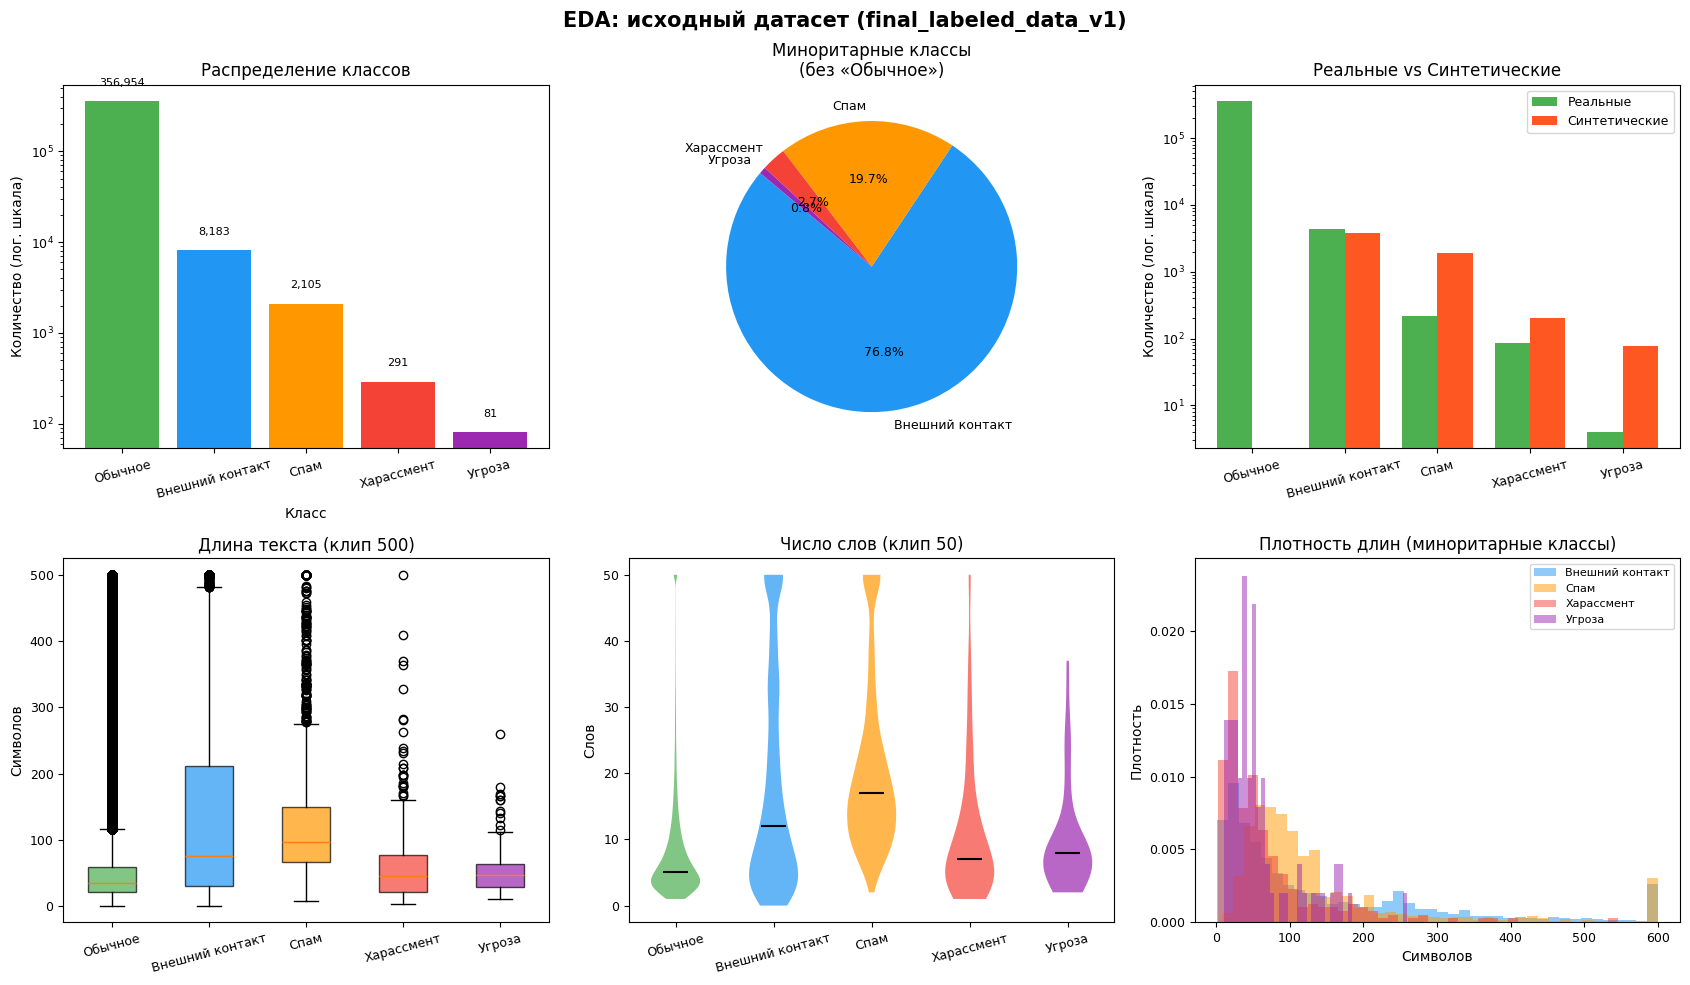

In [6]:
fig = full_eda_grid(df_eda, title="EDA: исходный датасет (final_labeled_data_v1)",
                    save_path="eda_report_initial.png")
plt.show()


In [7]:
print("=== Примеры по классам (только реальные) ===")
for cls in CLASS_ORDER:
    subset = df_eda[(df_eda["label"] == cls) & (df_eda["source"] == "real")]["text"].dropna()
    n_real = len(subset)
    print(f"\n{'─'*60}")
    print(f"Класс: {CLASS_RU[cls]} | Реальных: {n_real}")
    print(f"{'─'*60}")
    for txt in subset.sample(min(3, n_real), random_state=42):
        print(f"  {str(txt)[:120]}")


=== Примеры по классам (только реальные) ===



────────────────────────────────────────────────────────────
Класс: Обычное | Реальных: 356954
────────────────────────────────────────────────────────────
  Здравствуйте, вы заберете?
  Заказ готов
  Добрый день да, сможем подскажите пожалуйста где находится объект?

────────────────────────────────────────────────────────────
Класс: Внешний контакт | Реальных: 4327
────────────────────────────────────────────────────────────
  Пришлите номер телефона, пожалуйста, к которому привязан ватсап, далее будем по заказу общаться там❤️
  Хорошо в телеграмм пришлем
  +72589612180

────────────────────────────────────────────────────────────
Класс: Спам | Реальных: 220
────────────────────────────────────────────────────────────
  Здравствуйте\uD83D\uDC4B 

Вы обратились в федеральную сеть по продаже электроники MIRAPHONE. 
 
Хотите узнать больше о 
  Здравствуйте, меня зовут Ауди, Вас приветствует компания Черри-Ремонт. Вы просматривали нашу вакансию. Ожидаем Вас с пон
  Спасибо, что откликну

## 4. Подготовка тренировочного датасета

### Стратегия:
1. **Объединяем** raw (с `message_id`) + labeled (с метками) — через текст
2. **Очищаем**: удаляем NaN, дубли, строки < 2 символов
3. **Ограничиваем** класс `normal` сверху (не нарушая реальные пропорции) — иначе модель выучит тривиальное «всё нормально»
4. **Синтетические** примеры идут **только в train** — val/test содержат исключительно реальные данные


In [8]:
# Объединение
df_merged = merge_with_labels(raw, labeled)
print(f"После merge: {len(df_merged):,} строк")
print(f"Наличие message_id: {df_merged['message_id'].notna().sum():,} реальных строк")


После merge: 367,744 строк
Наличие message_id: 361,600 реальных строк


In [9]:
# Очистка
df_clean = clean(df_merged)
df_clean = add_text_features(df_clean)

print("\n=== После очистки ===")
display(quality_report(df_clean))


Очистка: 367,744 → 367,341 строк (удалено 403)



=== После очистки ===


,Всего,Реальных,Синтетических,% синтетики,Ср. длина
Класс,,,,,
normal,356865,356865,0,0.0,55.0
external,8003,4327,3676,45.9,151.6
spam,2101,220,1881,89.5,142.7
harassment,291,87,204,70.1,65.5
threat,81,4,77,95.1,59.7


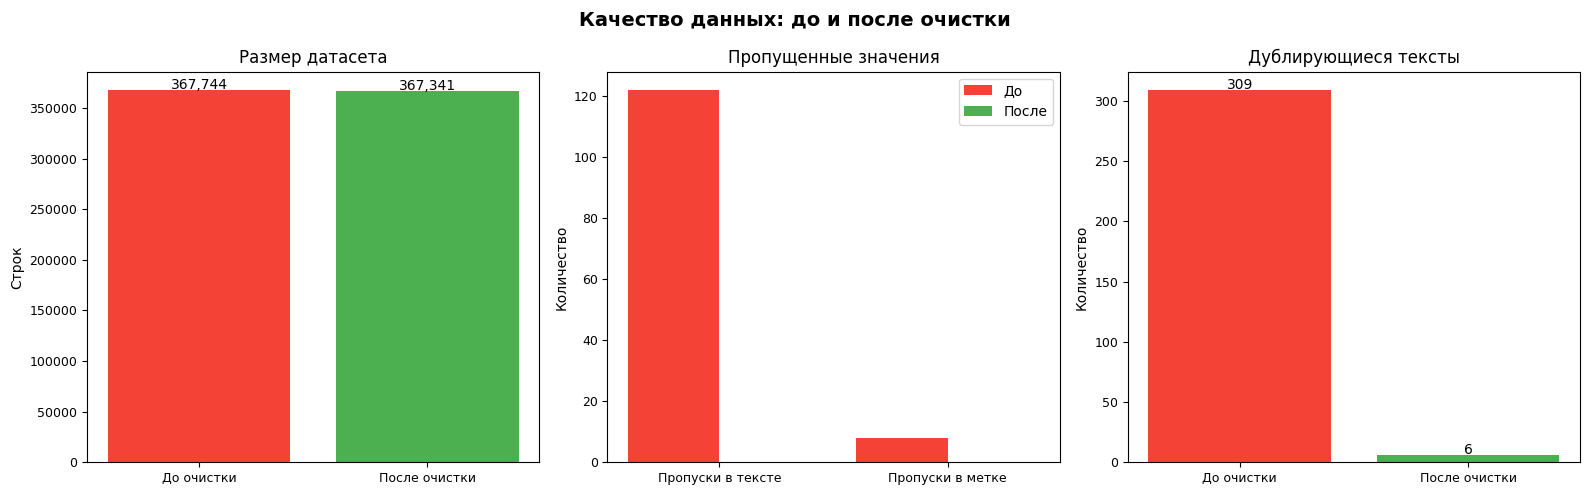

In [10]:
fig_q = plot_quality_issues(
    df_merged.rename(columns={"label": "label"}),
    df_clean,
    save_path="eda_quality.png"
)
plt.show()



Датасет после балансировки: 50,476 строк

=== Распределение классов ===


label
normal        40000
external       8003
spam           2101
harassment      291
threat           81
Name: count, dtype: int64

Сохранено: eda_report_balanced.png


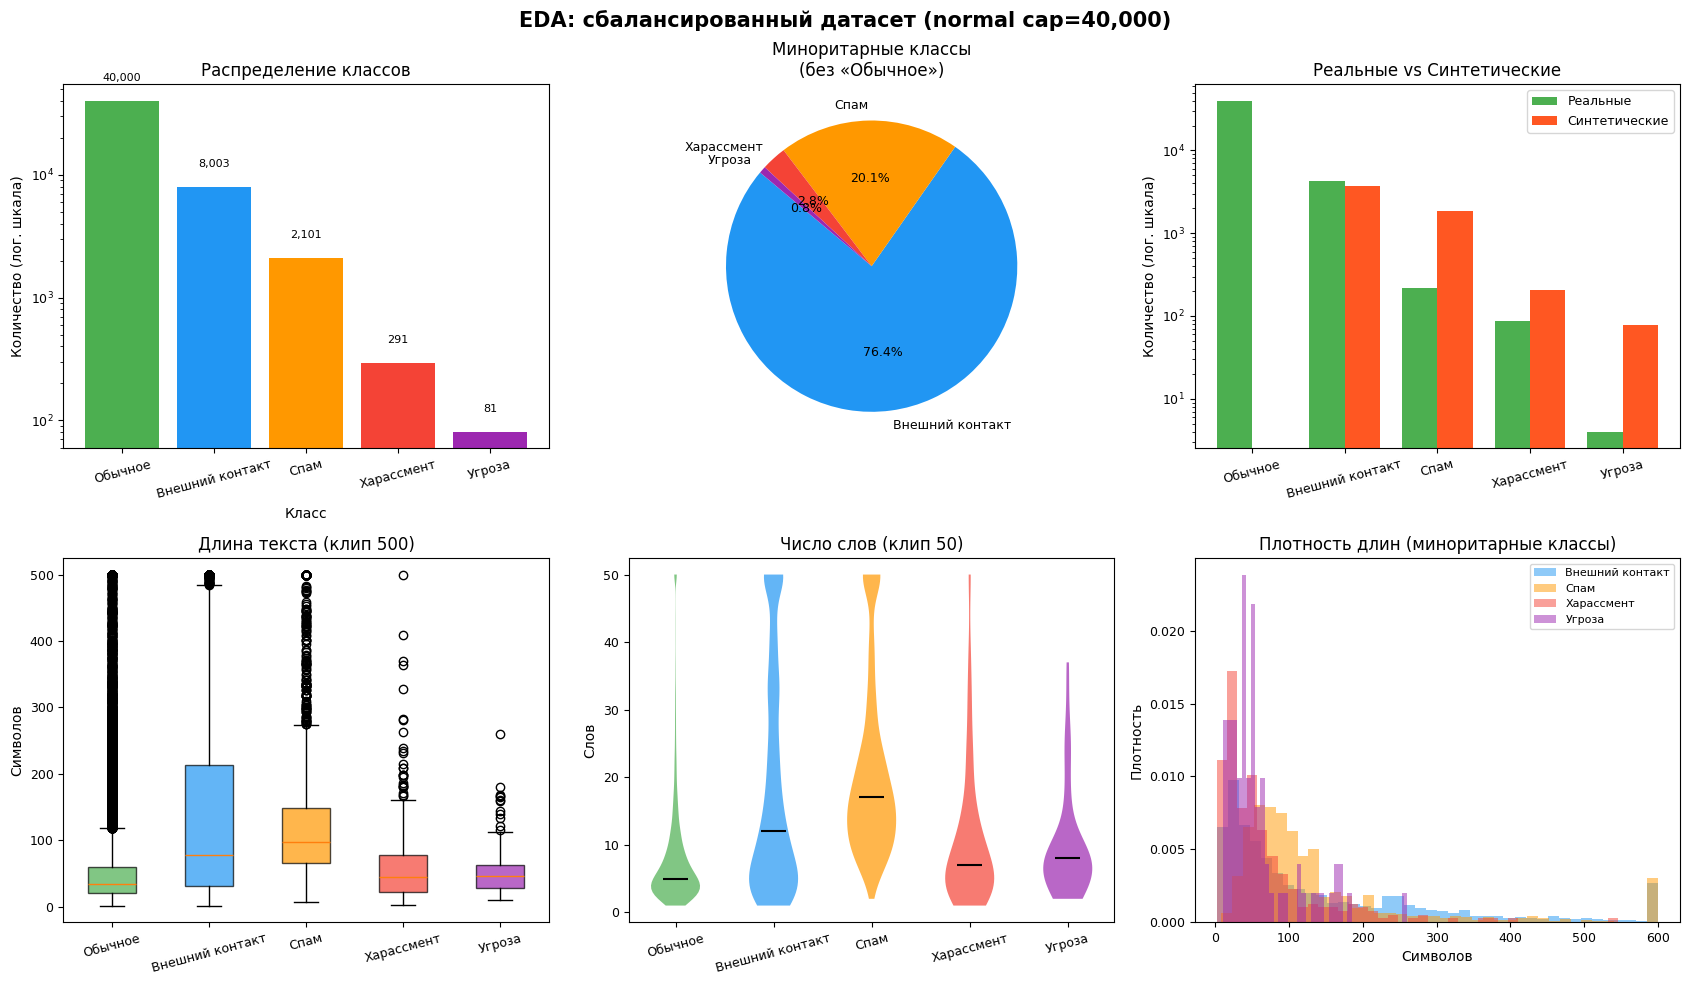

In [11]:
# Балансировка
df_train_ready = make_train_ready(df_clean, normal_cap=NORMAL_CAP)

print(f"\nДатасет после балансировки: {len(df_train_ready):,} строк")
print("\n=== Распределение классов ===")
display(df_train_ready["label"].value_counts().rename("count"))

fig2 = full_eda_grid(df_train_ready,
                      title=f"EDA: сбалансированный датасет (normal cap={NORMAL_CAP:,})",
                      save_path="eda_report_balanced.png")
plt.show()


## 5. Train / Val / Test разбивка

**Правило**: val и test — **только реальные** примеры.
Синтетические данные остаются в train.


In [12]:
train, val, test = split(df_train_ready, val_size=0.10, test_size=0.10)

stats = split_stats(train, val, test)

print("=== Train ===")
display(train["label"].value_counts().rename("count"))
print(f"  из них синтетических: {(train['source']=='synthetic').sum():,}")

print("\n=== Val ===")
display(val["label"].value_counts().rename("count"))

print("\n=== Test ===")
display(test["label"].value_counts().rename("count"))


=== Train ===


label
normal        32000
external       7139
spam           2057
harassment      275
threat           79
Name: count, dtype: int64

  из них синтетических: 5,838

=== Val ===


label
normal        4000
external       432
spam            22
harassment       8
threat           1
Name: count, dtype: int64


=== Test ===


label
normal        4000
external       432
spam            22
harassment       8
threat           1
Name: count, dtype: int64

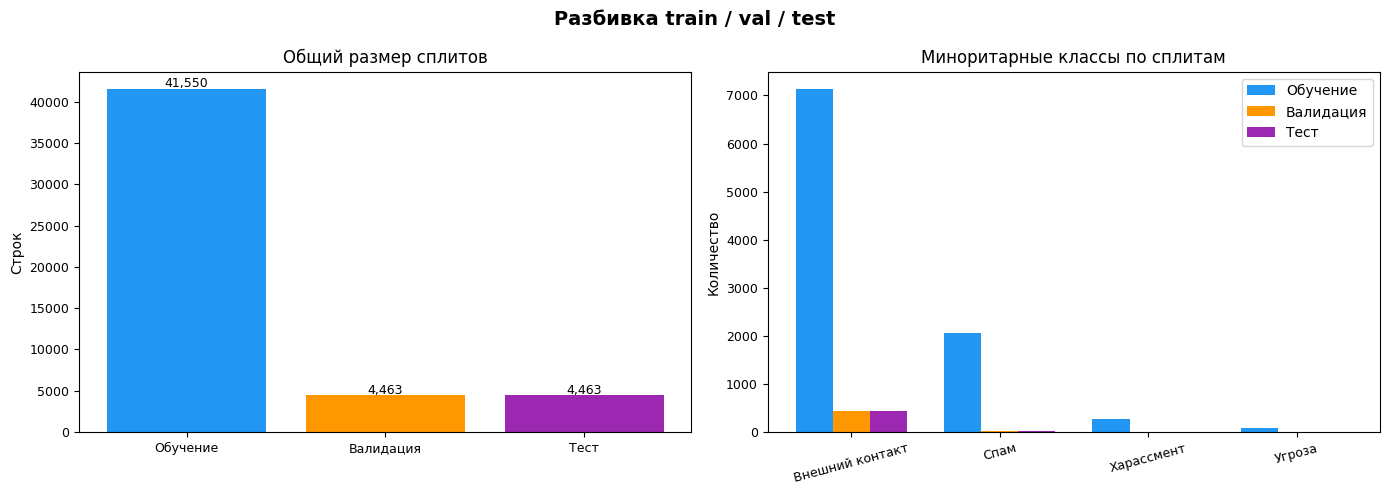

In [13]:
fig3 = plot_train_val_test_split(stats, save_path="eda_splits.png")
plt.show()


In [14]:
# Сохраняем на диск
save_splits(train, val, test, out_dir="data/processed")
print("\nКолонки в train.csv:", train.columns.tolist())


Сохранено в data/processed:
  train.csv — 41,550 строк
  val.csv   — 4,463 строк
  test.csv  — 4,463 строк

Колонки в train.csv: ['text', 'label', 'synthetic', 'source', 'message_id', 'item_title', 'text_len', 'word_count']


## 6. Итоги и выводы

### Результат подготовки данных

| | Исходный | После очистки | Train | Val | Test |
|---|---|---|---|---|---|
| Строк | 367 744 | ~367 000 | см. ниже | см. ниже | см. ниже |
| % синтетики | 1.7% | 1.7% | содержит | 0% | 0% |


In [15]:
summary = {
    "Исходный датасет":   len(labeled),
    "После очистки":      len(df_clean),
    "Train (с синтетикой)": len(train),
    "Val (только real)":  len(val),
    "Test (только real)": len(test),
}
print("=== Сводка размеров ===")
for k, v in summary.items():
    print(f"  {k:<28}: {v:>8,}")

print("\n=== Финальное качество: таблица по классам ===")
display(quality_report(df_clean))


=== Сводка размеров ===
  Исходный датасет            :  367,744
  После очистки               :  367,341
  Train (с синтетикой)        :   41,550
  Val (только real)           :    4,463
  Test (только real)          :    4,463

=== Финальное качество: таблица по классам ===


,Всего,Реальных,Синтетических,% синтетики,Ср. длина
Класс,,,,,
normal,356865,356865,0,0.0,55.0
external,8003,4327,3676,45.9,151.6
spam,2101,220,1881,89.5,142.7
harassment,291,87,204,70.1,65.5
threat,81,4,77,95.1,59.7


### Выводы

1. **Дисбаланс — главная проблема**: 97% сообщений — класс «normal». При обучении обязательно использовать `class_weight='balanced'` или oversampling (SMOTE на эмбеддингах).

2. **Синтетика**: для `threat` — 95% синтетики, для `harassment` — 70%. Без неё датасет практически непригоден для обучения миноритарных классов. Качество синтетических примеров нужно контролировать.

3. **Разбивка val/test — только real**: это гарантирует честную оценку модели на реальных данных (без утечки синтетики в метрики).

4. **Рекомендуемые метрики**: Precision ≥ 0.95 по классу `normal` (бизнес-требование), macro-F1 для остальных классов. Матрица ошибок с акцентом на минимизацию FN для `threat` и `harassment`.

5. **Следующий шаг**: обучение классификатора на базе предобученного многоязычного encoder'а (например, `cointegrated/rubert-tiny2` или `DeepPavlov/rubert-base-cased`) с fine-tuning на подготовленном train.csv.
